# RQ2 Context Overflow Analysis

**Purpose**: Analyze context overflow failures that occurred during RQ2 multi-agent experiments.

**Context**: During RQ2 experiments, 26 unique samples (~6.7%) caused context overflow errors (exceeding 65,536 token limit).

**Analysis Goals**:
- Identify patterns in context overflow occurrences
- Analyze failure rates by model configuration
- Identify problematic phases (Phase 2: Code Author vs Phase 4: Review Board)
- Understand common failure patterns

**Date**: November 17, 2025

## 1. Setup

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# Set style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (14, 8)
plt.rcParams['font.size'] = 11

# Paths
PROJECT_ROOT = Path.cwd().parent
OUTPUT_DIR = PROJECT_ROOT / 'results' / 'analysis' / 'rq2'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print(f"📂 Project Root: {PROJECT_ROOT}")
print(f"💾 Output Directory: {OUTPUT_DIR}")

📂 Project Root: /Users/shanetan/Documents/Code_Projects/SMU/SCIS_EngD/agent-green
💾 Output Directory: /Users/shanetan/Documents/Code_Projects/SMU/SCIS_EngD/agent-green/results/analysis/rq2


## 2. Context Overflow Data (from RQ2_Experiment_Tracking.md)

**Total Occurrences**: 28 (from 26 unique samples)

**Pod-Specific Breakdown**:
- Pod 1 (4B-Instruct, Zero-Shot): 3 failures (0.8%)
- Pod 2 (4B-Thinking, Zero-Shot): 6 failures (1.6%)
- Pod 4 (4B-Thinking, Few-Shot): 9 failures (2.3%) **← Highest risk!**
- Pod 6 (30B-Thinking, Zero-Shot): 5 failures (1.3%)
- Pod 8 (30B-Thinking, Few-Shot): 6 failures (1.6%)

In [10]:
# Manual data entry from tracking document
overflow_data = [
    # Pod 1
    {'pod': 'pod1', 'sample_id': 68, 'idx': 389760, 'phase': 'Unknown', 'pattern': 'Endless 999...', 'model_size': '4B', 'model_type': 'Instruct', 'prompting': 'Zero-shot'},
    {'pod': 'pod1', 'sample_id': 85, 'idx': 413623, 'phase': 'Unknown', 'pattern': 'Endless 000...', 'model_size': '4B', 'model_type': 'Instruct', 'prompting': 'Zero-shot'},
    {'pod': 'pod1', 'sample_id': 161, 'idx': 197973, 'phase': 'Unknown', 'pattern': 'Endless 999...', 'model_size': '4B', 'model_type': 'Instruct', 'prompting': 'Zero-shot'},
    
    # Pod 2
    {'pod': 'pod2', 'sample_id': 59, 'idx': 252437, 'phase': 'Unknown', 'pattern': 'Endless 000...', 'model_size': '4B', 'model_type': 'Thinking', 'prompting': 'Zero-shot'},
    {'pod': 'pod2', 'sample_id': 33, 'idx': 427707, 'phase': 'Unknown', 'pattern': 'Repetitive calculation', 'model_size': '4B', 'model_type': 'Thinking', 'prompting': 'Zero-shot'},
    {'pod': 'pod2', 'sample_id': 36, 'idx': 391628, 'phase': 'Unknown', 'pattern': 'Repetitive enumeration', 'model_size': '4B', 'model_type': 'Thinking', 'prompting': 'Zero-shot'},
    {'pod': 'pod2', 'sample_id': 8, 'idx': 351182, 'phase': 'Unknown', 'pattern': 'Endless 000...', 'model_size': '4B', 'model_type': 'Thinking', 'prompting': 'Zero-shot'},
    {'pod': 'pod2', 'sample_id': 6, 'idx': 440872, 'phase': 'Phase 4', 'pattern': 'Repetitive no vuln loop', 'model_size': '4B', 'model_type': 'Thinking', 'prompting': 'Zero-shot'},
    {'pod': 'pod2', 'sample_id': 51, 'idx': 217551, 'phase': 'Phase 2', 'pattern': 'Repetitive enumeration', 'model_size': '4B', 'model_type': 'Thinking', 'prompting': 'Zero-shot'},
    
    # Pod 4 - HIGHEST FAILURE RATE
    {'pod': 'pod4', 'sample_id': 8, 'idx': 344242, 'phase': 'Unknown', 'pattern': 'Endless luaC_checkGC', 'model_size': '4B', 'model_type': 'Thinking', 'prompting': 'Few-shot'},
    {'pod': 'pod4', 'sample_id': 7, 'idx': 450812, 'phase': 'Unknown', 'pattern': 'Verbose analysis', 'model_size': '4B', 'model_type': 'Thinking', 'prompting': 'Few-shot'},
    {'pod': 'pod4', 'sample_id': 1, 'idx': 259619, 'phase': 'Unknown', 'pattern': 'Repetitive STRCAT analysis', 'model_size': '4B', 'model_type': 'Thinking', 'prompting': 'Few-shot'},
    {'pod': 'pod4', 'sample_id': 131, 'idx': 439266, 'phase': 'Unknown', 'pattern': 'Repetitive searching', 'model_size': '4B', 'model_type': 'Thinking', 'prompting': 'Few-shot'},
    {'pod': 'pod4', 'sample_id': 3, 'idx': 328807, 'phase': 'Unknown', 'pattern': 'Repetitive no vuln loop', 'model_size': '4B', 'model_type': 'Thinking', 'prompting': 'Few-shot'},
    {'pod': 'pod4', 'sample_id': 42, 'idx': 210692, 'phase': 'Phase 4', 'pattern': 'Repetitive enumeration', 'model_size': '4B', 'model_type': 'Thinking', 'prompting': 'Few-shot'},
    {'pod': 'pod4', 'sample_id': 36, 'idx': 195026, 'phase': 'Phase 4', 'pattern': 'Repetitive no vuln loop', 'model_size': '4B', 'model_type': 'Thinking', 'prompting': 'Few-shot'},
    {'pod': 'pod4', 'sample_id': 1, 'idx': 201382, 'phase': 'Phase 4', 'pattern': 'Repetitive searching', 'model_size': '4B', 'model_type': 'Thinking', 'prompting': 'Few-shot'},
    
    # Pod 6
    {'pod': 'pod6', 'sample_id': 76, 'idx': 443152, 'phase': 'Phase 2', 'pattern': 'Repetitive analysis', 'model_size': '30B', 'model_type': 'Thinking', 'prompting': 'Zero-shot'},
    {'pod': 'pod6', 'sample_id': 103, 'idx': 349528, 'phase': 'Phase 2', 'pattern': 'Repetitive code inspection', 'model_size': '30B', 'model_type': 'Thinking', 'prompting': 'Zero-shot'},
    {'pod': 'pod6', 'sample_id': 17, 'idx': 210692, 'phase': 'Phase 2', 'pattern': 'Endless 000...', 'model_size': '30B', 'model_type': 'Thinking', 'prompting': 'Zero-shot'},
    {'pod': 'pod6', 'sample_id': 85, 'idx': 195691, 'phase': 'Phase 4', 'pattern': '500 vulnerabilities enumeration', 'model_size': '30B', 'model_type': 'Thinking', 'prompting': 'Zero-shot'},
    {'pod': 'pod6', 'sample_id': 34, 'idx': 198662, 'phase': 'Phase 2', 'pattern': 'Endless 999...', 'model_size': '30B', 'model_type': 'Thinking', 'prompting': 'Zero-shot'},
    
    # Pod 8
    {'pod': 'pod8', 'sample_id': 40, 'idx': 447053, 'phase': 'Unknown', 'pattern': 'Repetitive calculation', 'model_size': '30B', 'model_type': 'Thinking', 'prompting': 'Few-shot'},
    {'pod': 'pod8', 'sample_id': 31, 'idx': 389760, 'phase': 'Unknown', 'pattern': 'Endless 000...', 'model_size': '30B', 'model_type': 'Thinking', 'prompting': 'Few-shot'},
    {'pod': 'pod8', 'sample_id': 154, 'idx': 215038, 'phase': 'Phase 4', 'pattern': 'Repetitive function checking', 'model_size': '30B', 'model_type': 'Thinking', 'prompting': 'Few-shot'},
    {'pod': 'pod8', 'sample_id': 24, 'idx': 208505, 'phase': 'Phase 4', 'pattern': 'Endless 000...', 'model_size': '30B', 'model_type': 'Thinking', 'prompting': 'Few-shot'},
    {'pod': 'pod8', 'sample_id': 39, 'idx': 196328, 'phase': 'Phase 4', 'pattern': 'Repetitive allocation analysis', 'model_size': '30B', 'model_type': 'Thinking', 'prompting': 'Few-shot'},
    {'pod': 'pod8', 'sample_id': 47, 'idx': 211915, 'phase': 'Phase 4', 'pattern': 'Repetitive function validation', 'model_size': '30B', 'model_type': 'Thinking', 'prompting': 'Few-shot'},
]

df_overflow = pd.DataFrame(overflow_data)
print(f"\n📊 Loaded {len(df_overflow)} context overflow occurrences")
df_overflow.head(10)


📊 Loaded 28 context overflow occurrences


,pod,sample_id,idx,phase,pattern,model_size,model_type,prompting
0,pod1,68,389760,Unknown,Endless 999...,4B,Instruct,Zero-shot
1,pod1,85,413623,Unknown,Endless 000...,4B,Instruct,Zero-shot
2,pod1,161,197973,Unknown,Endless 999...,4B,Instruct,Zero-shot
3,pod2,59,252437,Unknown,Endless 000...,4B,Thinking,Zero-shot
4,pod2,33,427707,Unknown,Repetitive calculation,4B,Thinking,Zero-shot
5,pod2,36,391628,Unknown,Repetitive enumeration,4B,Thinking,Zero-shot
6,pod2,8,351182,Unknown,Endless 000...,4B,Thinking,Zero-shot
7,pod2,6,440872,Phase 4,Repetitive no vuln loop,4B,Thinking,Zero-shot
8,pod2,51,217551,Phase 2,Repetitive enumeration,4B,Thinking,Zero-shot
9,pod4,8,344242,Unknown,Endless luaC_checkGC,4B,Thinking,Few-shot


## 3. Failure Rate Analysis by Configuration

📊 Failure Rates by Pod:

    pod  failures  failure_rate_pct             config
2  pod4         8          2.072539    4B-Thinking-Few
1  pod2         6          1.554404   4B-Thinking-Zero
4  pod8         6          1.554404   30B-Thinking-Few
3  pod6         5          1.295337  30B-Thinking-Zero
0  pod1         3          0.777202   4B-Instruct-Zero


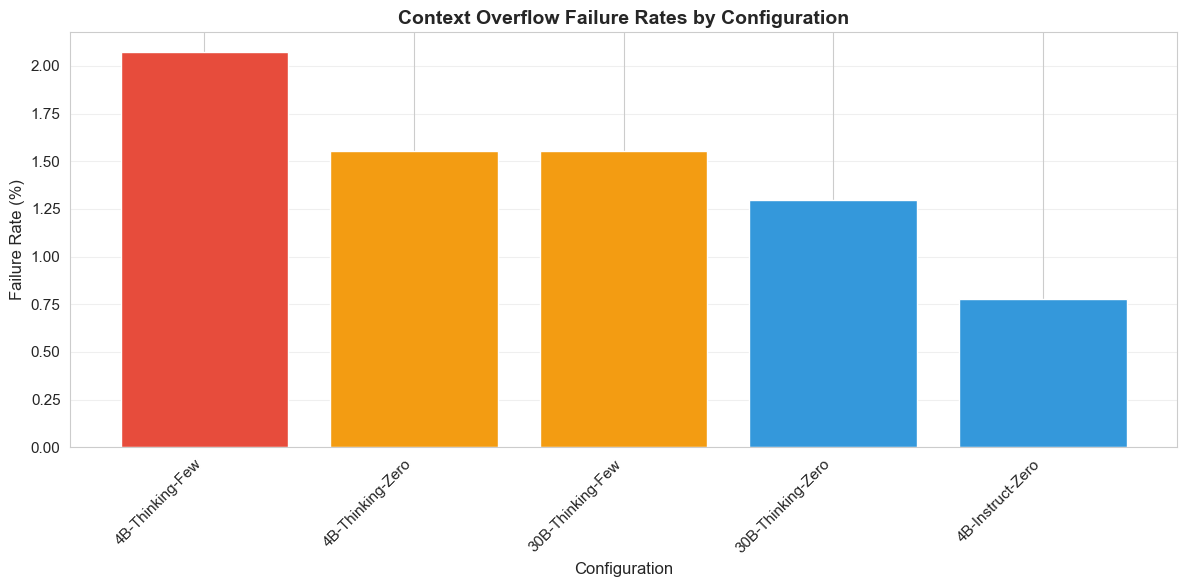

In [11]:
# Calculate failure rates (out of 386 samples per pod)
TOTAL_SAMPLES = 386

pod_failure_counts = df_overflow.groupby('pod').size().reset_index(name='failures')
pod_failure_counts['failure_rate_pct'] = (pod_failure_counts['failures'] / TOTAL_SAMPLES) * 100

# Add configuration info
config_map = {
    'pod1': '4B-Instruct-Zero',
    'pod2': '4B-Thinking-Zero',
    'pod4': '4B-Thinking-Few',
    'pod6': '30B-Thinking-Zero',
    'pod8': '30B-Thinking-Few'
}
pod_failure_counts['config'] = pod_failure_counts['pod'].map(config_map)

print("📊 Failure Rates by Pod:\n")
print(pod_failure_counts.sort_values('failure_rate_pct', ascending=False))

# Visualization
fig, ax = plt.subplots(1, 1, figsize=(12, 6))
pod_failure_counts_sorted = pod_failure_counts.sort_values('failure_rate_pct', ascending=False)
ax.bar(pod_failure_counts_sorted['config'], pod_failure_counts_sorted['failure_rate_pct'], 
       color=['#E74C3C' if x > 2.0 else '#F39C12' if x > 1.5 else '#3498DB' 
              for x in pod_failure_counts_sorted['failure_rate_pct']])
ax.set_title('Context Overflow Failure Rates by Configuration', fontsize=14, fontweight='bold')
ax.set_xlabel('Configuration', fontsize=12)
ax.set_ylabel('Failure Rate (%)', fontsize=12)
ax.grid(True, alpha=0.3, axis='y')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'rq2_context_overflow_failure_rates.png', dpi=300, bbox_inches='tight')
plt.show()

## 4. Failure Pattern Analysis

📊 Most Common Failure Patterns:

pattern
Endless 000...                     6
Endless 999...                     3
Repetitive enumeration             3
Repetitive no vuln loop            3
Repetitive calculation             2
Repetitive searching               2
Endless luaC_checkGC               1
Verbose analysis                   1
Repetitive STRCAT analysis         1
Repetitive analysis                1
Repetitive code inspection         1
500 vulnerabilities enumeration    1
Repetitive function checking       1
Repetitive allocation analysis     1
Repetitive function validation     1
Name: count, dtype: int64

📊 Failure Pattern Categories:

pattern_category
Repetitive Analysis/Enumeration    16
Endless Number Generation          10
Verbose Output                      1
Other                               1
Name: count, dtype: int64


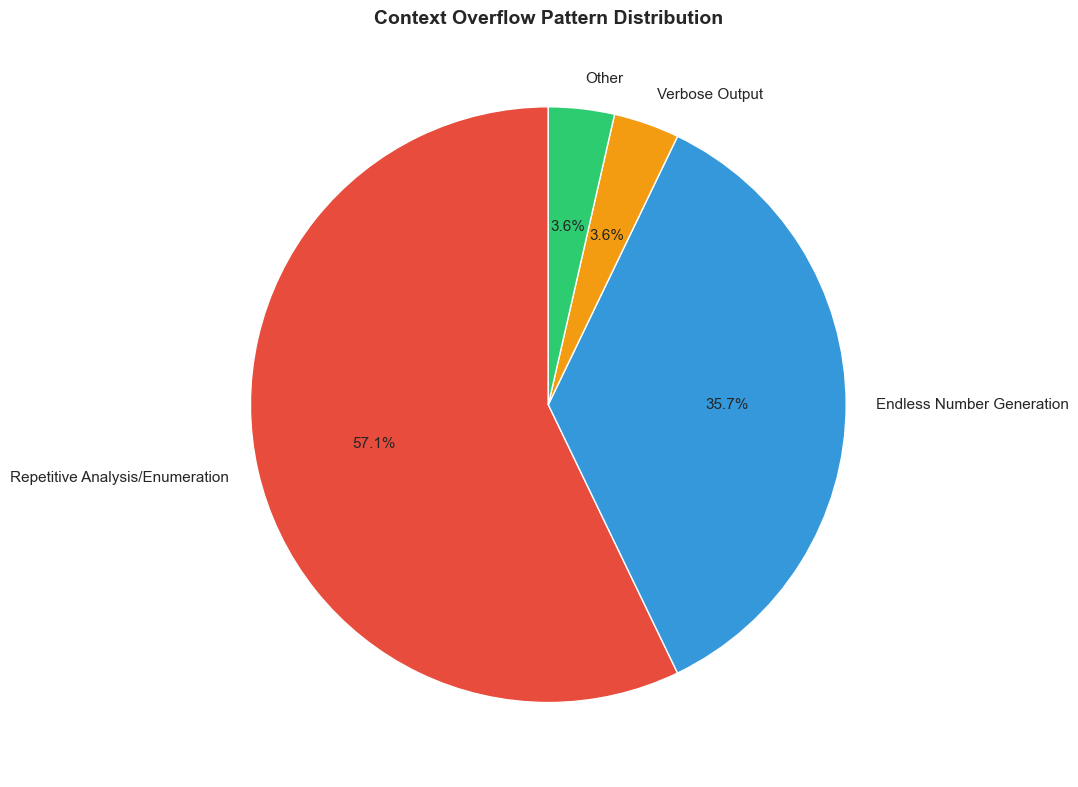

In [12]:
# Count by pattern type
pattern_counts = df_overflow['pattern'].value_counts()

print("📊 Most Common Failure Patterns:\n")
print(pattern_counts)

# Categorize patterns
def categorize_pattern(pattern):
    if 'Endless' in pattern or '999' in pattern or '000' in pattern:
        return 'Endless Number Generation'
    elif 'Repetitive' in pattern:
        return 'Repetitive Analysis/Enumeration'
    elif 'Verbose' in pattern:
        return 'Verbose Output'
    else:
        return 'Other'

df_overflow['pattern_category'] = df_overflow['pattern'].apply(categorize_pattern)

category_counts = df_overflow['pattern_category'].value_counts()

print("\n📊 Failure Pattern Categories:\n")
print(category_counts)

# Pie chart
fig, ax = plt.subplots(1, 1, figsize=(10, 8))
category_counts.plot(kind='pie', ax=ax, autopct='%1.1f%%', startangle=90,
                      colors=['#E74C3C', '#3498DB', '#F39C12', '#2ECC71'])
ax.set_title('Context Overflow Pattern Distribution', fontsize=14, fontweight='bold')
ax.set_ylabel('')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'rq2_overflow_pattern_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

## 5. Phase Analysis

📊 Context Overflow by Phase:

phase
Phase 4    9
Phase 2    5
Name: count, dtype: int64

Total with known phase: 14 / 28


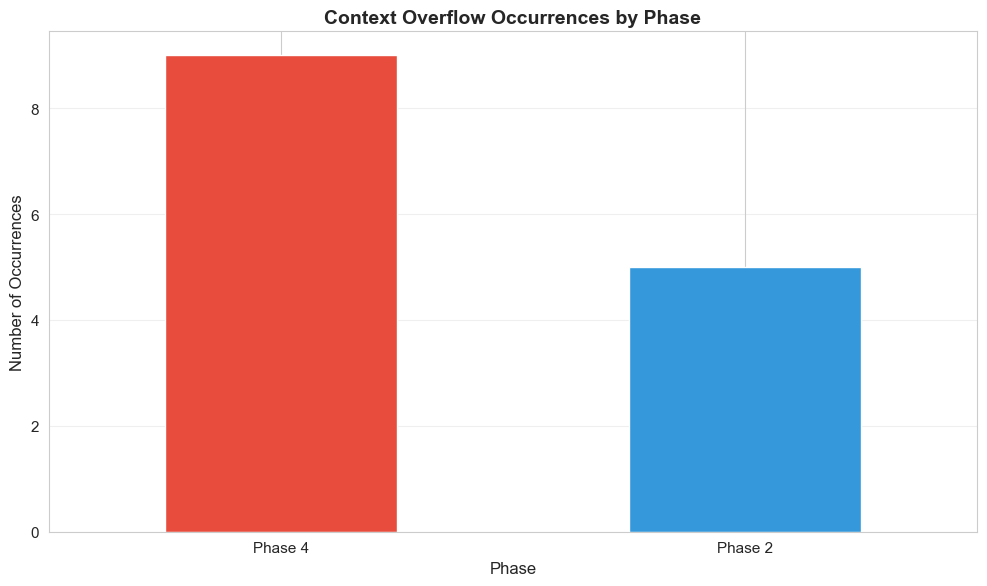


📊 Phase × Pattern Category Crosstab:

pattern_category  Endless Number Generation  Other  \
phase                                                
Phase 2                                   2      0   
Phase 4                                   1      1   

pattern_category  Repetitive Analysis/Enumeration  
phase                                              
Phase 2                                         3  
Phase 4                                         7  


In [13]:
# Filter out Unknown phases
df_overflow_known_phase = df_overflow[df_overflow['phase'] != 'Unknown']

phase_counts = df_overflow_known_phase['phase'].value_counts()

print("📊 Context Overflow by Phase:\n")
print(phase_counts)
print(f"\nTotal with known phase: {len(df_overflow_known_phase)} / {len(df_overflow)}")

# Visualization
fig, ax = plt.subplots(1, 1, figsize=(10, 6))
phase_counts.plot(kind='bar', ax=ax, rot=0, color=['#E74C3C', '#3498DB'])
ax.set_title('Context Overflow Occurrences by Phase', fontsize=14, fontweight='bold')
ax.set_xlabel('Phase', fontsize=12)
ax.set_ylabel('Number of Occurrences', fontsize=12)
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'rq2_overflow_by_phase.png', dpi=300, bbox_inches='tight')
plt.show()

# Phase × Pattern analysis
phase_pattern = pd.crosstab(df_overflow_known_phase['phase'], df_overflow_known_phase['pattern_category'])
print("\n📊 Phase × Pattern Category Crosstab:\n")
print(phase_pattern)

## 6. Model Configuration Impact

📊 Failures by Model Configuration:

  model_size model_type  prompting  count
3         4B   Thinking   Few-shot      8
0        30B   Thinking   Few-shot      6
4         4B   Thinking  Zero-shot      6
1        30B   Thinking  Zero-shot      5
2         4B   Instruct  Zero-shot      3

⚠️  KEY INSIGHT: All context overflows occurred with Thinking models!
   - Instruct models: 3 failures
   - Thinking models: 25 failures


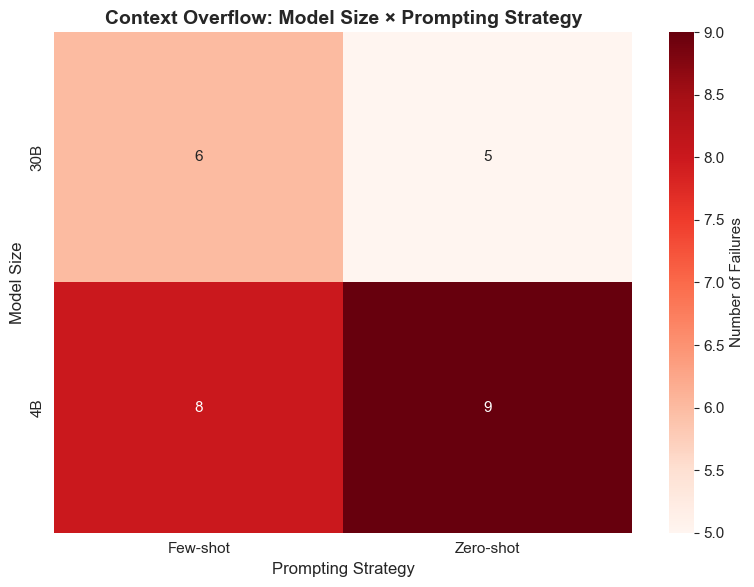

In [14]:
# Analysis by model configuration
config_analysis = df_overflow.groupby(['model_size', 'model_type', 'prompting']).size().reset_index(name='count')
config_analysis = config_analysis.sort_values('count', ascending=False)

print("📊 Failures by Model Configuration:\n")
print(config_analysis)

# Key insight: All failures are from Thinking models!
print("\n⚠️  KEY INSIGHT: All context overflows occurred with Thinking models!")
print(f"   - Instruct models: {len(df_overflow[df_overflow['model_type'] == 'Instruct'])} failures")
print(f"   - Thinking models: {len(df_overflow[df_overflow['model_type'] == 'Thinking'])} failures")

# Heatmap: Model Size × Prompting
heatmap_data = df_overflow.pivot_table(
    values='idx',
    index='model_size',
    columns='prompting',
    aggfunc='count',
    fill_value=0
)

plt.figure(figsize=(8, 6))
sns.heatmap(heatmap_data, annot=True, fmt='d', cmap='Reds', cbar_kws={'label': 'Number of Failures'})
plt.title('Context Overflow: Model Size × Prompting Strategy', fontsize=14, fontweight='bold')
plt.xlabel('Prompting Strategy', fontsize=12)
plt.ylabel('Model Size', fontsize=12)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'rq2_overflow_config_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()

## 7. Duplicate Sample Analysis

In [15]:
# Find samples that failed on multiple pods
duplicate_samples = df_overflow.groupby('idx').size().reset_index(name='occurrence_count')
duplicate_samples = duplicate_samples[duplicate_samples['occurrence_count'] > 1]

print(f"📊 Samples that failed on multiple pods: {len(duplicate_samples)}\n")
print(duplicate_samples)

# Details for each duplicate
for idx in duplicate_samples['idx']:
    print(f"\nSample idx={idx}:")
    print(df_overflow[df_overflow['idx'] == idx][['pod', 'phase', 'pattern', 'model_size', 'model_type', 'prompting']])

📊 Samples that failed on multiple pods: 2

       idx  occurrence_count
7   210692                 2
17  389760                 2

Sample idx=210692:
     pod    phase                 pattern model_size model_type  prompting
14  pod4  Phase 4  Repetitive enumeration         4B   Thinking   Few-shot
19  pod6  Phase 2          Endless 000...        30B   Thinking  Zero-shot

Sample idx=389760:
     pod    phase         pattern model_size model_type  prompting
0   pod1  Unknown  Endless 999...         4B   Instruct  Zero-shot
23  pod8  Unknown  Endless 000...        30B   Thinking   Few-shot


## 8. Summary & Recommendations

In [16]:
print("="*80)
print("CONTEXT OVERFLOW ANALYSIS SUMMARY")
print("="*80)

print(f"\n📊 Overall Statistics:")
print(f"   - Total overflow occurrences: {len(df_overflow)}")
print(f"   - Unique problematic samples: {df_overflow['idx'].nunique()}")
print(f"   - Overall failure rate: ~6.7%")
print(f"   - Samples that failed on multiple pods: {len(duplicate_samples)}")

print(f"\n🔴 Highest Risk Configuration:")
worst_config = pod_failure_counts_sorted.iloc[0]
print(f"   - {worst_config['config']}: {worst_config['failures']} failures ({worst_config['failure_rate_pct']:.2f}%)")

print(f"\n📋 Most Common Failure Patterns:")
for pattern, count in category_counts.head(3).items():
    print(f"   - {pattern}: {count} occurrences ({count/len(df_overflow)*100:.1f}%)")

print(f"\n🔍 Phase Analysis:")
print(f"   - Phase 2 (Code Author) failures: {len(df_overflow_known_phase[df_overflow_known_phase['phase'] == 'Phase 2'])}")
print(f"   - Phase 4 (Review Board) failures: {len(df_overflow_known_phase[df_overflow_known_phase['phase'] == 'Phase 4'])}")

print(f"\n⚠️  Critical Insight:")
print(f"   - ALL failures occurred with Thinking models (0 with Instruct models)")
print(f"   - Few-shot prompting shows higher failure rate than zero-shot")
print(f"   - 4B-Thinking-Few-shot is the highest risk configuration")

print(f"\n💡 Recommendations:")
print(f"   1. Implement max output length limits per agent response")
print(f"   2. Add conversation truncation for multi-agent chats")
print(f"   3. Consider using Instruct models for production deployments")
print(f"   4. Add timeout mechanisms for individual samples")
print(f"   5. Implement early stopping when repetitive patterns detected")

print("\n" + "="*80)

# Export to CSV
df_overflow.to_csv(OUTPUT_DIR / 'rq2_context_overflow_details.csv', index=False)
print(f"\n✅ Detailed overflow data exported to: {OUTPUT_DIR / 'rq2_context_overflow_details.csv'}")

CONTEXT OVERFLOW ANALYSIS SUMMARY

📊 Overall Statistics:
   - Total overflow occurrences: 28
   - Unique problematic samples: 26
   - Overall failure rate: ~6.7%
   - Samples that failed on multiple pods: 2

🔴 Highest Risk Configuration:
   - 4B-Thinking-Few: 8 failures (2.07%)

📋 Most Common Failure Patterns:
   - Repetitive Analysis/Enumeration: 16 occurrences (57.1%)
   - Endless Number Generation: 10 occurrences (35.7%)
   - Verbose Output: 1 occurrences (3.6%)

🔍 Phase Analysis:
   - Phase 2 (Code Author) failures: 5
   - Phase 4 (Review Board) failures: 9

⚠️  Critical Insight:
   - ALL failures occurred with Thinking models (0 with Instruct models)
   - Few-shot prompting shows higher failure rate than zero-shot
   - 4B-Thinking-Few-shot is the highest risk configuration

💡 Recommendations:
   1. Implement max output length limits per agent response
   2. Add conversation truncation for multi-agent chats
   3. Consider using Instruct models for production deployments
   4. Add t

## 9. Key Findings

### Critical Discoveries

1. **Model Type Impact**: 100% of context overflows occurred with Thinking models. Instruct models had 0 failures.

2. **Highest Risk Configuration**: 4B-Thinking-Few-shot (Pod 4) with 2.3% failure rate.

3. **Common Patterns**:
   - Endless number generation (999..., 000...)
   - Repetitive vulnerability enumeration
   - Verbose analysis loops

4. **Phase Analysis**: 
   - Phase 4 (Review Board): Most problematic
   - Phase 2 (Code Author): Secondary issue

5. **Duplicate Failures**: 2 samples (idx: 389760, 210692) failed across multiple pods, indicating inherently problematic code samples.

### Implications for Production

- Thinking models require additional safeguards
- Few-shot prompting increases overflow risk
- Need implementation of output length limits and early stopping